-> Cargando base de datos para el Nodo: AMBA...
Iniciando sintonización de hiperparámetros (Auto-ARIMA)...

Estructura paramétrica seleccionada:
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 2160
Model:             SARIMAX(2, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -12160.129
Date:                            Wed, 10 Jun 2026   AIC                          24336.258
Time:                                    11:59:34   BIC                          24381.678
Sample:                                10-03-2025   HQIC                         24352.871
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------

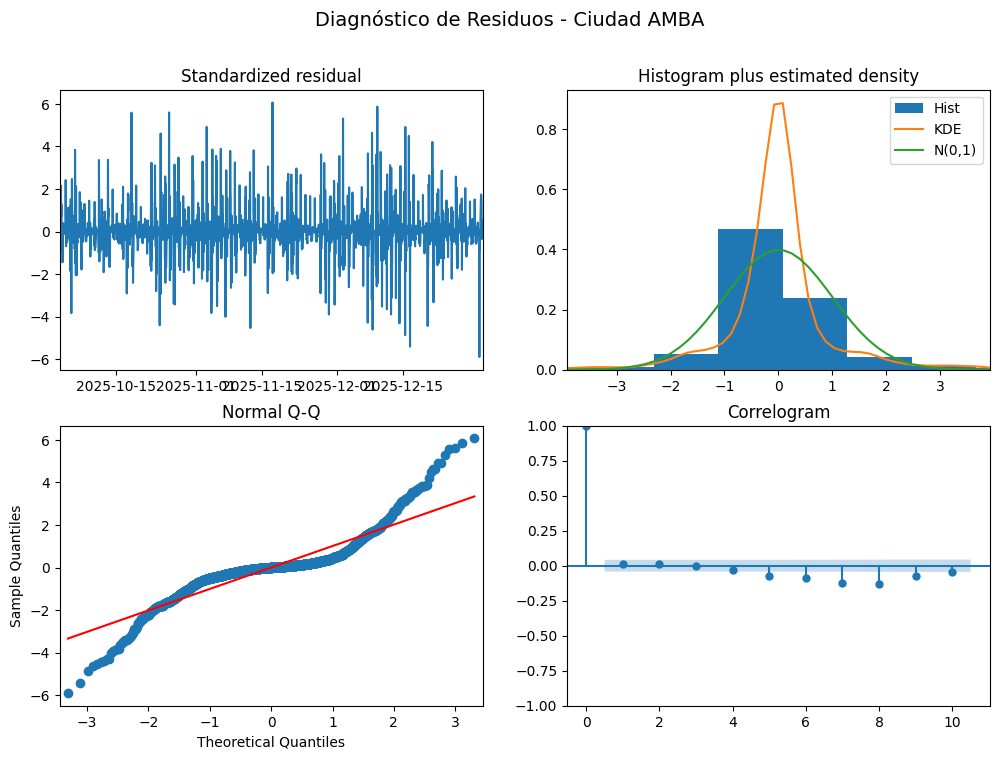

 Archivo del modelo físico guardado en: c:\Users\54113\Desktop\Sistema_inteligencia_climatica\4_salidas\entrenamiento_sarimax\modelo_sarimax_ciudad_amba.pkl
 Métricas registradas con éxito en: c:\Users\54113\Desktop\Sistema_inteligencia_climatica\4_salidas\entrenamiento_sarimax\log_entrenamiento_sarimax.csv


In [ ]:

# CUADERNO: sarimax_entrenamiento
# Objetivo: Sintonización de AMBA con diagnóstico de residuos y guardado físico.


import sys
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import os
import pmdarima as pm
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
#  DETECCIÓN DINÁMICA DE LA RAÍZ DEL PROYECTO
# Path.cwd() obtiene la carpeta donde está el cuaderno ('2_cuadernos')
# .parent sube un nivel a la carpeta principal ('Sistema_inteligencia_climatica')
PROJECT_ROOT = Path.cwd().parent



RUTA_LIMPIA = PROJECT_ROOT / "1_datos" / "procesados" / "base_climatica_limpia.csv"

# Definición de subcarpeta en 4_salidas para organización del entrenamiento SARIMAX
CARPETA_ENTRENAMIENTO = PROJECT_ROOT / "4_salidas" / "entrenamiento_sarimax"

# Crear la carpeta de entrenamiento automáticamente si no existe
CARPETA_ENTRENAMIENTO.mkdir(parents=True, exist_ok=True)

#  DETECCIÓN DINÁMICA DE LA RAÍZ DEL PROYECTO
# Path.cwd() obtiene la carpeta donde está el cuaderno ('2_cuadernos')
# .parent sube un nivel a la carpeta principal ('Sistema_inteligencia_climatica')
PROJECT_ROOT = Path.cwd().parent


CIUDAD_OBJETIVO = "amba"
TARGET = 'radiacion_solar(ALLSKY)'
EXOG_VARS = ['temperatura_media(T2M)', 'velocidad_viento(WS10M)', 
             'nubosidad_promedio(CLOUD_AMT)', 'humedad_relativa(RH2M)']

#  CARGA Y PREPARACIÓN DE LA SERIE TEMPORAL
print(f"-> Cargando base de datos para el Nodo: {CIUDAD_OBJETIVO.upper()}...")
try:
    df_solar = pd.read_csv(RUTA_LIMPIA)
    df_c = df_solar[df_solar['ciudad_id'] == CIUDAD_OBJETIVO].copy()
    df_c['dt'] = pd.to_datetime(df_c['fecha']) + pd.to_timedelta(df_c['hora'], unit='h')
    df_modelo = df_c.set_index('dt').asfreq('h') # Frecuencia horaria vital 

    # ALGORITMO AUTO-ARIMA (Tuning)
    # Acotar a 2160 horas (3 meses) para evitar MemoryError 
    df_muestra = df_modelo.dropna().iloc[-2160:]
    y_train = df_muestra[TARGET]
    X_train = df_muestra[EXOG_VARS]

    print("Iniciando sintonización de hiperparámetros (Auto-ARIMA)...")
    model_auto = pm.auto_arima(
        y=y_train, X=X_train, 
        seasonal=True, m=24,         # Ciclo solar de 24 horas 
        stepwise=True,               # Convergencia rápida
        suppress_warnings=True, 
        error_action="ignore", 
        max_p=2, max_q=2,            # Límites 
        max_P=1, max_Q=1
    )

    print("\nEstructura paramétrica seleccionada:")
    print(model_auto.summary())

    #  GENERACIÓN Y GUARDADO DE GRÁFICOS DE DIAGNÓSTICO
    print("\n Generando y guardando gráficos de diagnóstico...")
    fig = model_auto.plot_diagnostics(figsize=(12, 8))
    plt.suptitle(f"Diagnóstico de Residuos - Ciudad {CIUDAD_OBJETIVO.upper()}", fontsize=14)

    ruta_grafico = CARPETA_ENTRENAMIENTO / f'diagnostico_residuos_{CIUDAD_OBJETIVO}.png'
    plt.savefig(ruta_grafico, dpi=300, bbox_inches='tight')
    print(f" Imagen del gráfico guardada con éxito en: {ruta_grafico}")
    plt.show()

    #  GUARDADO DEL MODELO FÍSICO Y MÉTRICAS
    try:
        # Guardar el modelo físico entrenado (.pkl)
        ruta_modelo = CARPETA_ENTRENAMIENTO / f'modelo_sarimax_ciudad_{CIUDAD_OBJETIVO}.pkl'
        joblib.dump(model_auto, ruta_modelo)
        print(f" Archivo del modelo físico guardado en: {ruta_modelo}")

        # Registro de métricas AIC y BIC en el log 
        RUTA_LOG = CARPETA_ENTRENAMIENTO / 'log_entrenamiento_sarimax.csv'
        log_data = {
            'ciudad_nombre': [CIUDAD_OBJETIVO],
            'order': [str(model_auto.order)],
            'seasonal_order': [str(model_auto.seasonal_order)],
            'aic': [model_auto.aic()],
            'bic': [model_auto.bic()],
            'fecha_ejecucion': [pd.Timestamp.now()]
        }
        df_log = pd.DataFrame(log_data)
        df_log.to_csv(RUTA_LOG, mode='a', index=False, header=not os.path.exists(RUTA_LOG))
        print(f" Métricas registradas con éxito en: {RUTA_LOG}")

    except Exception as e:
        print(f" Error en el bloque de guardado: {e}") 

except Exception as e:
    print(f"Error al cargar los datos: {e}") 